In [17]:
from pathlib import Path

import pandas as pd

RAW_PATH = Path("../data/france/food_france.csv.gz")
WORK_PATH = Path("../data/france/food_france_work.parquet")  # ton Parquet à toi, plat
SEP = "\t"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [18]:
all_columns = pd.read_csv(RAW_PATH, sep=SEP, nrows=0).columns.tolist()
print(len(all_columns), "colonnes")

211 colonnes


In [19]:
NUMERIC_COLS = [
    "energy-kcal_100g", "energy_100g",
    "fat_100g", "saturated-fat_100g",
    "sugars_100g", "salt_100g", "sodium_100g",
    "fiber_100g", "proteins_100g",
]

CATEGORY_COLS = ["nutriscore_grade", "nova_group", "countries_tags"]

TEXT_COLS = ["code", "product_name", "brands", "quantity", "categories_tags", "image_url"]

COLS = TEXT_COLS + CATEGORY_COLS + NUMERIC_COLS

missing = set(COLS) - set(all_columns)
assert not missing, f"Colonnes introuvables : {missing}"

DTYPES = (
    {c: "float32" for c in NUMERIC_COLS}
    | {c: "category" for c in CATEGORY_COLS}
    | {c: "string" for c in TEXT_COLS}
)

In [20]:
df = pd.read_csv(RAW_PATH, sep=SEP, usecols=COLS, dtype=DTYPES)
df.to_parquet(WORK_PATH)

print(f"{len(df):,} lignes, {df.memory_usage(deep=True).sum() / 1e6:.0f} Mo")

1,261,263 lignes, 339 Mo


In [21]:
df = pd.read_parquet(WORK_PATH)

In [22]:
completeness = df.notna().mean().mul(100).round(1).sort_values()
completeness

nova_group            27.30
fiber_100g            29.80
quantity              36.60
categories_tags       50.30
brands                53.50
salt_100g             65.10
sodium_100g           65.10
saturated-fat_100g    69.20
sugars_100g           69.30
fat_100g              69.30
proteins_100g         69.40
energy-kcal_100g      69.90
energy_100g           69.90
product_name          89.60
image_url             92.40
nutriscore_grade      97.90
code                 100.00
countries_tags       100.00
dtype: float64

In [23]:
dup_mask = df["code"].duplicated(keep=False)
print(f"{dup_mask.sum():,} lignes concernées, {df.loc[dup_mask, 'code'].nunique():,} codes distincts")

df.loc[dup_mask].sort_values("code")[["code", "product_name", "brands"]].head(20)

52 lignes concernées, 26 codes distincts


,code,product_name,brands
18992,0059527070430,Goji Snack Bars,Taste Of Nature
18993,0059527070430,Goji,Taste of Nature
18998,0059527171687,Pomegranate,Taste of Nature
18999,0059527171687,Tast Of Nature Pomegranate Granenreep @,Taste of nature
19019,0059527401555,Almond Fruit And Nut Snack Bar,Taste Of Nature
19020,0059527401555,Almond,Taste of Nature
19021,0059527501552,Cranberry Fruit and Nut Snack Bar,Taste Of Nature
19022,0059527501552,Cranberry,Taste of Nature
19025,0059527601559,Brazil nut,Taste of Nature
19026,0059527601559,"Coconut, Cranberry, Brazil Nut Snack Bar Varie...",Taste Of Nature


In [24]:
checks = {
    "sucres > 100 g/100 g": df["sugars_100g"] > 100,
    "sucres < 0": df["sugars_100g"] < 0,
    "graisses > 100": df["fat_100g"] > 100,
    "sel > 100": df["salt_100g"] > 100,
    "énergie kcal = 0": df["energy-kcal_100g"] == 0,
    "énergie kcal > 900": df["energy-kcal_100g"] > 900,  # la matière grasse pure vaut ~900
    "sucres > glucides": df["sugars_100g"] > 100,  # à raffiner plus tard
}
pd.Series({name: int(mask.sum()) for name, mask in checks.items()})

sucres > 100 g/100 g       53
sucres < 0                  0
graisses > 100             45
sel > 100                  60
énergie kcal = 0        17665
énergie kcal > 900       1145
sucres > glucides          53
dtype: int64

In [25]:
# kJ ≈ 4,184 × kcal
ratio = df["energy_100g"] / df["energy-kcal_100g"]
ratio.describe(percentiles=[.01, .5, .99])

# sel ≈ 2,5 × sodium
(df["salt_100g"] / df["sodium_100g"]).describe(percentiles=[.01, .5, .99])

c:\Users\Administrateur\Documents\Programmation\tp_fil_rouge\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\Administrateur\Documents\Programmation\tp_fil_rouge\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count   713857.00
mean          inf
std           NaN
min          0.00
1%           2.50
50%          2.50
99%          2.52
max           inf
dtype: float64

In [26]:
df["nutriscore_grade"].value_counts(dropna=False, normalize=True).mul(100).round(1)

nutriscore_grade
unknown          57.00
e                10.60
d                 9.90
c                 7.80
a                 5.20
b                 4.10
not-applicable    3.30
NaN               2.10
Name: proportion, dtype: float64

In [27]:
df[NUMERIC_COLS].describe(percentiles=[.01, .25, .5, .75, .99]).T

c:\Users\Administrateur\Documents\Programmation\tp_fil_rouge\.venv\Lib\site-packages\pandas\core\nanops.py:1037: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)


,count,mean,std,min,1%,25%,50%,75%,99%,max
energy-kcal_100g,881281.00,16150008832.00,15161074122752.00,-113.86,0.00,113.00,262.00,400.00,828.00,14232695911481344.00
energy_100g,881613.00,12510.07,10650285.00,-700.00,0.00,477.60,1089.80,1671.90,3404.00,10000000000.00
fat_100g,874248.00,14.30,18.73,-0.00,0.00,1.00,8.10,22.30,92.00,3257.00
saturated-fat_100g,873052.00,5.42,8.32,-3.62,0.00,0.20,2.00,8.00,29.00,1238.00
sugars_100g,874227.00,1343721343649565507038740480.00,inf,0.00,0.00,0.60,3.50,19.50,80.50,1174717435652793984888552594341888.00
salt_100g,821330.00,1.28,9.27,0.00,0.00,0.07,0.54,1.30,13.00,5000.00
sodium_100g,821330.00,0.52,4.47,0.00,0.00,0.03,0.22,0.52,5.20,2000.00
fiber_100g,375761.00,3.09,12.47,-0.42,0.00,0.02,1.50,3.60,26.00,6636.00
proteins_100g,875886.00,9.05,45.17,-0.01,0.00,1.50,6.30,13.00,41.08,40939.00


<Axes: ylabel='Frequency'>

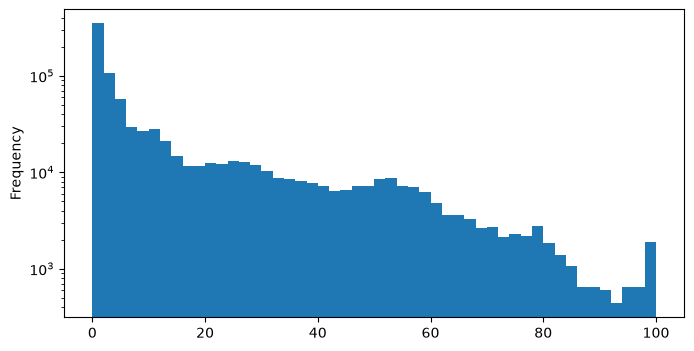

In [28]:
df["sugars_100g"].clip(upper=100).plot.hist(bins=50, log=True, figsize=(8, 4))